In [1]:
from kan import *
import torch
torch.cuda.empty_cache()
from sklearn.metrics import mean_absolute_error
import os
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu" )
print(device)

cuda:3


In [3]:
hust_data = torch.load('../Data/HUST_Data_Var2.pt')
print(hust_data)

/tmp/ipykernel_1685414/4138673366.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  hust_data = torch.load('../Data/HUST_Data_Var2.pt')


{'train_input': tensor([[ 1.0000, -1.0000],
        [ 0.9212, -0.9926],
        [ 0.9212, -0.9911],
        ...,
        [-0.9999,  0.9984],
        [-1.0000,  0.9992],
        [-0.9648,  1.0000]], device='cuda:3'), 'train_label': tensor([[1.0726],
        [1.0724],
        [1.0725],
        ...,
        [0.8012],
        [0.8009],
        [0.8004]], device='cuda:3'), 'test_input': tensor([[ 1.0000, -1.0000],
        [ 0.9692, -0.9988],
        [ 0.9692, -0.9976],
        ...,
        [-0.7998,  0.9947],
        [-0.7999,  0.9991],
        [-0.7999,  1.0000]], device='cuda:3'), 'test_label': tensor([[1.0639],
        [1.0633],
        [1.0634],
        ...,
        [0.8037],
        [0.8021],
        [0.8021]], device='cuda:3'), 'train_diff_input': tensor([[ 1.0000, -1.0000],
        [ 0.9212, -0.9926],
        [ 0.9212, -0.9911],
        ...,
        [-0.9999,  0.9984],
        [-1.0000,  0.9992],
        [-0.9648,  1.0000]], device='cuda:3'), 'train_diff_label': tensor([[1.0726],
   

In [4]:
hust_dataset = {
        'train_input': hust_data['train_input'],
        'train_label': hust_data['train_label'],
        'test_input': hust_data['test_input'],
        'test_label': hust_data['test_label']
    }
hust_dataset_cpu = {
        'train_input': hust_data['train_input'].to('cpu'),
        'train_label': hust_data['train_label'].to('cpu'),
        'test_input': hust_data['test_input'].to('cpu'),
        'test_label': hust_data['test_label'].to('cpu')
    }

In [5]:
kan_hust = KAN(width=[2,5,5,1], grid=3, k=3, seed=25, ckpt_path='../Notebooks/ckpt_path/kan_hust_var2/',device=device)

checkpoint directory created: ../Notebooks/ckpt_path/kan_hust_var2/
saving model version 0.0


In [6]:
results = kan_hust.fit(
    dataset=hust_dataset,
    opt="LBFGS",    
    loss_fn=torch.nn.MSELoss(),  # Change loss function to MSE
    lamb=0.001,
    steps=50,
    save_fig=True,
    img_folder='../Images/kan_hust_var2/video_img_f1'
)

description:   0%|                                                           | 0/50 [00:00<?, ?it/s]

| train_loss: 1.26e-02 | test_loss: 1.15e-02 | reg: 2.97e+00 | : 100%|█| 50/50 [05:53<00:00,  7.07s/

saving model version 0.1


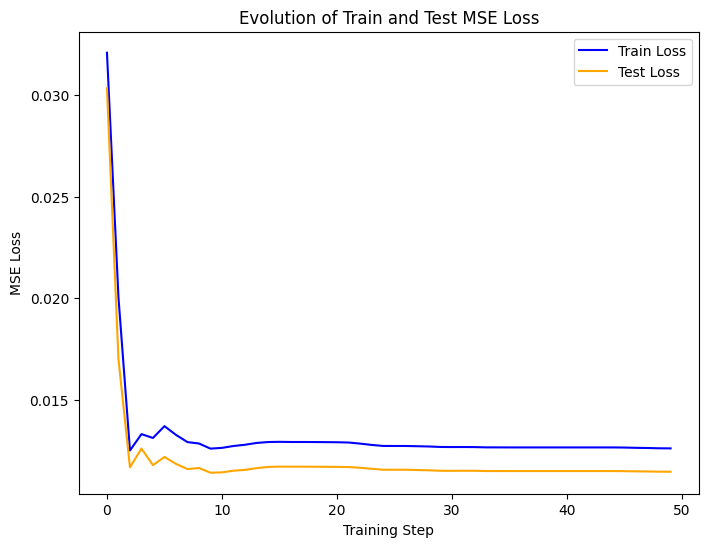

In [7]:
# Assuming results['train_mse'] and results['test_mse'] are lists of MSE values for each training step
train_losses = results['train_loss']
test_losses = results['test_loss']
# Plot the evolution of train and test loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(test_losses, label="Test Loss", color="orange")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Evolution of Train and Test MSE Loss")
plt.legend()
# Save the plot to a specific location
save_path = '../Images/kan_hust_var2/paper_img/train_and_test_loss_f1.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
plt.show()

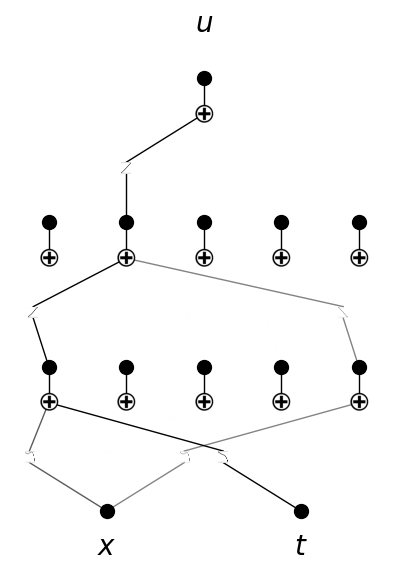

In [8]:
kan_hust.plot(folder="../Images/kan_hust_var2/paper_img/kan_f1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$']) # beta=50, scale=1,

saving model version 0.2


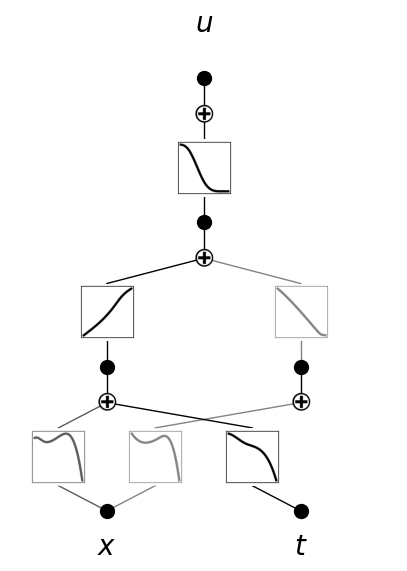

In [9]:
kan_hust = kan_hust.prune()
kan_hust.plot(folder="../Images/kan_hust_var2/paper_img/kan_p1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

In [10]:
results = kan_hust.fit(
    dataset=hust_dataset,
    opt="LBFGS",    #LBFGS
    loss_fn=torch.nn.MSELoss(),  # Change loss function to MSE
    steps=50,
    save_fig=True,
    img_folder='../Images/kan_hust_var2/video_img_f2'
)

| train_loss: 1.02e-02 | test_loss: 9.96e-03 | reg: 4.09e+00 | : 100%|█| 50/50 [01:49<00:00,  2.19s/

saving model version 0.3


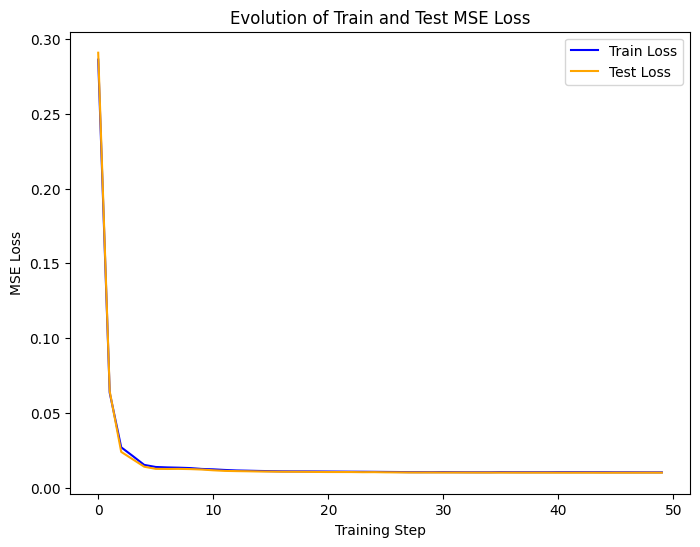

In [11]:
# Assuming results['train_mse'] and results['test_mse'] are lists of MSE values for each training step
train_losses = results['train_loss']
test_losses = results['test_loss']
# Plot the evolution of train and test loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(test_losses, label="Test Loss", color="orange")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Evolution of Train and Test MSE Loss")
plt.legend()
# Save the plot to a specific location
save_path = '../Images/kan_hust_var2/paper_img/train_and_test_loss_f2.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
plt.show()

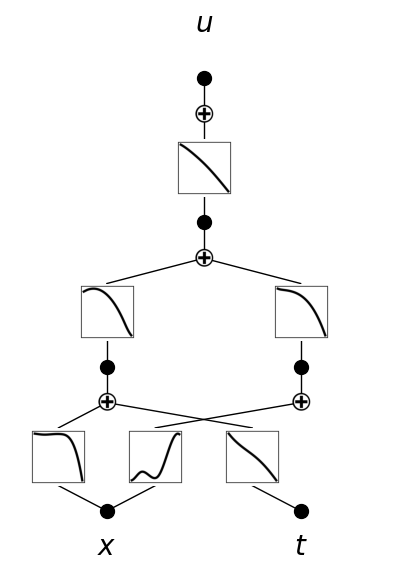

In [12]:
kan_hust.plot(folder="../Images/kan_hust_var2/paper_img/kan_f2/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

In [13]:
add_symbolic('sigmoid', torch.sigmoid)
add_symbolic('relu',torch.relu)
add_symbolic('cosh',torch.cosh)
add_symbolic('sinh',torch.sinh)
add_symbolic('arcsinh',torch.arcsinh)
add_symbolic('arccosh',torch.arccosh)

kan_hust.auto_symbolic()

fixing (0,0,0) with sigmoid, r2=0.9969256520271301, c=1
fixing (0,0,1) with relu, r2=0.9642082452774048, c=1
fixing (0,1,0) with sinh, r2=0.9997845888137817, c=1
fixing (0,1,1) with 0
fixing (1,0,0) with cosh, r2=0.996234655380249, c=1
fixing (1,1,0) with cosh, r2=0.9928008913993835, c=1
fixing (2,0,0) with cosh, r2=0.9999200105667114, c=1
saving model version 0.4


In [ ]:
formula, variables = kan_hust.symbolic_formula()
print(formula[0])
print(ex_round(formula[0],2))

173.545654296875 - 172.352584838867*cosh(0.288072663074963*cosh(0.0190105298898438 - 0.158667227999596*relu(6.53648042678833*x_1 - 0.991999804973602)) + 0.670035877386674*cosh(-0.841316827842945*sigmoid(5.68824005126953 - 6.37008047103882*x_1) - 0.0439358936297509*sinh(-1.17079985141754*x_2 - 0.216879993677139) + 0.377527755992677) - 1.07531508445803)
173.55 - 172.35*cosh(0.29*cosh(0.02 - 0.16*relu(6.54*x_1 - 0.99)) + 0.67*cosh(-0.84*sigmoid(5.69 - 6.37*x_1) - 0.04*sinh(-1.17*x_2 - 0.22) + 0.38) - 1.08)


In [15]:
def complex_expression1(x):
    # Unpack inputs
    x_1, x_2 = x

    # First part of the expression
    Eq = 173.545654296875 - 172.352584838867*torch.cosh(0.288072663074963*torch.cosh(0.0190105298898438 - 0.158667227999596*torch.relu(6.53648042678833*x_1 - 0.991999804973602)) \
        + 0.670035877386674*torch.cosh(-0.841316827842945*torch.sigmoid(5.68824005126953 - 6.37008047103882*x_1) \
        - 0.0439358936297509*torch.sinh(-1.17079985141754*x_2 - 0.216879993677139) + 0.377527755992677) - 1.07531508445803)

    # Return the result as a tensor
    return torch.tensor([Eq])

In [ ]:
# def complex_expression(x):
#     # Unpack inputs
#     x_1, x_2 = x

#     # First part of the expression
#     Eq = 173.545654296875 - 172.35*torch.cosh(0.29*torch.cosh(0.02 - 0.16*torch.relu(6.54*x_1 - 0.99)) + 0.67*torch.cosh(-0.84*torch.sigmoid(5.69 - 6.37*x_1) - 0.04*torch.sinh(-1.17*x_2 - 0.22) + 0.38) - 1.08)

#     # Return the result as a tensor
#     return torch.tensor([Eq])

In [19]:
def complex_expression(x):
    # Unpack inputs
    x_1, x_2 = x

    # First part of the expression
    Eq = 173.545654296875 - 172.353*torch.cosh(0.288*torch.cosh(0.019 - 0.159*torch.relu(6.536*x_1 - 0.992)) 
                                               + 0.670*torch.cosh(-0.841*torch.sigmoid(5.688 - 6.370*x_1) - 0.044*torch.sinh(-1.171*x_2 - 0.217) + 0.378) - 1.075)

    # Return the result as a tensor
    return torch.tensor([Eq])

In [20]:
kan_hust = KAN.loadckpt('../Notebooks/ckpt_path/kan_hust_var2/0.3')
kan_hust.get_act(hust_dataset)
# Access the true values (targets) from the test set
true_values = hust_dataset['test_label'].cpu().numpy()  # Convert to numpy for plotting

# Step 1: Make predictions on the test set using the KAN model
with torch.no_grad():
    test_predictions = kan_hust(hust_dataset['test_input'])

# Step 2: Convert tensors to NumPy arrays for plotting
kan_forecasts = test_predictions.cpu().numpy()

# Step 3: Use complex_expression function to create symbolic_forecast
symbolic_forecast = []
symbolic_forecast1 = []
with torch.no_grad():
    for i in range(hust_dataset['test_input'].shape[0]):
        # Extract each input set from the test dataset and pass it to complex_expression
        x = hust_dataset['test_input'][i]
        symbolic_result = complex_expression(x)  # Pass each sample to the complex expression
        symbolic_forecast.append(symbolic_result.cpu().numpy())  # Append to list after converting to numpy
        symbolic_result1 = complex_expression1(x)  # Pass each sample to the complex expression
        symbolic_forecast1.append(symbolic_result1.cpu().numpy())  # Append to list after converting to numpy

# Convert symbolic_forecast to a NumPy array for easier handling and plotting
symbolic_forecast = np.array(symbolic_forecast)
symbolic_forecast1 = np.array(symbolic_forecast1)

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

In [21]:
from sklearn import metrics
def eval_metrix(true_label,pred_label):
    MAE = metrics.mean_absolute_error(true_label,pred_label)
    MAPE = metrics.mean_absolute_percentage_error(true_label,pred_label)
    MSE = metrics.mean_squared_error(true_label,pred_label)
    RMSE = np.sqrt(metrics.mean_squared_error(true_label,pred_label))
    return [MAE,MAPE,MSE,RMSE]
# Assuming `kan_forecasts`, `symbolic_forecast`, and `true_values` are already defined and are NumPy arrays.
kan_metrics = eval_metrix(true_values, kan_forecasts)
symbolic_metrics = eval_metrix(true_values, symbolic_forecast)
symbolic_metrics1 = eval_metrix(true_values, symbolic_forecast1)
# Display the results
print(f"Metrics for KAN forecast: MAE:{kan_metrics[0]}, MAPE:{kan_metrics[1]}, MSE:{kan_metrics[2]}, RMSE:{kan_metrics[3]}")
print(f"Metrics for Symbolic forecast: MAE:{symbolic_metrics[0]}, MAPE:{symbolic_metrics[1]}, MSE:{symbolic_metrics[2]}, RMSE:{symbolic_metrics[3]}")
print(f"Metrics for Symbolic forecast 1: MAE:{symbolic_metrics1[0]}, MAPE:{symbolic_metrics1[1]}, MSE:{symbolic_metrics1[2]}, RMSE:{symbolic_metrics1[3]}")

Metrics for KAN forecast: MAE:0.008388432674109936, MAPE:0.00850469060242176, MSE:9.915789269143716e-05, RMSE:0.009957805275917053
Metrics for Symbolic forecast: MAE:0.011561919935047626, MAPE:0.011585977859795094, MSE:0.00025979793281294405, RMSE:0.016118248924613
Metrics for Symbolic forecast 1: MAE:0.011324532330036163, MAPE:0.011340201832354069, MSE:0.0002501404960639775, RMSE:0.01581582985818386


image saved at ../Images/kan_hust_var2/paper_img/reality_vs_Kan_vs_symbolic_first400.png


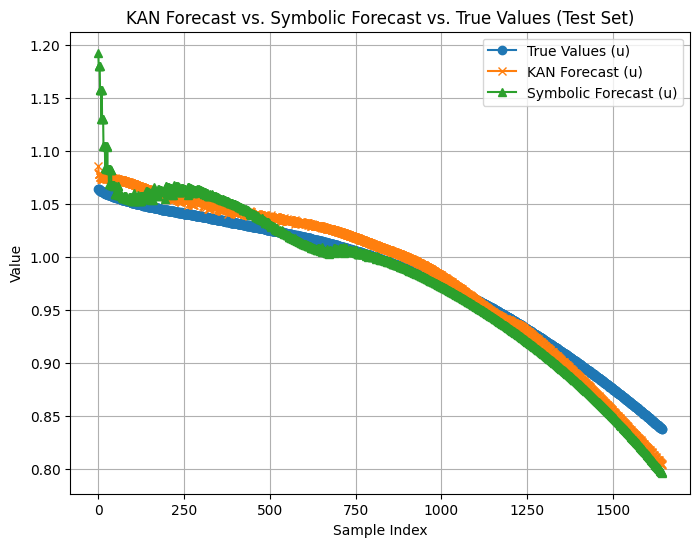

In [ ]:
import matplotlib.pyplot as plt

# Set the interval for the samples to plot
interval = 1644

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the KAN forecasts and symbolic forecasts against the true values for id_k1
plt.plot(true_values[:interval], label='True Values (u)', marker='o')
plt.plot(kan_forecasts[:interval], label='KAN Forecast (u)', marker='x')
plt.plot(symbolic_forecast1[:interval], label='Symbolic Forecast (u)', marker='^')
# plt.ylim(0.79, 1.01)
# plt.yticks(np.arange(0.80, 1.01, 0.05))

# Customize the plot
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('KAN Forecast vs. Symbolic Forecast vs. True Values (Test Set)')
plt.legend()
plt.grid(True)

# Save the plot to a specific location
save_path = f'../Images/kan_hust_var2/paper_img/reality_vs_Kan_vs_symbolic_first{interval}.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)

# Show the plot
plt.show()

image saved at ../Images/kan_hust_var2/paper_img/reality_vs_Kan_vs_symbolic.png


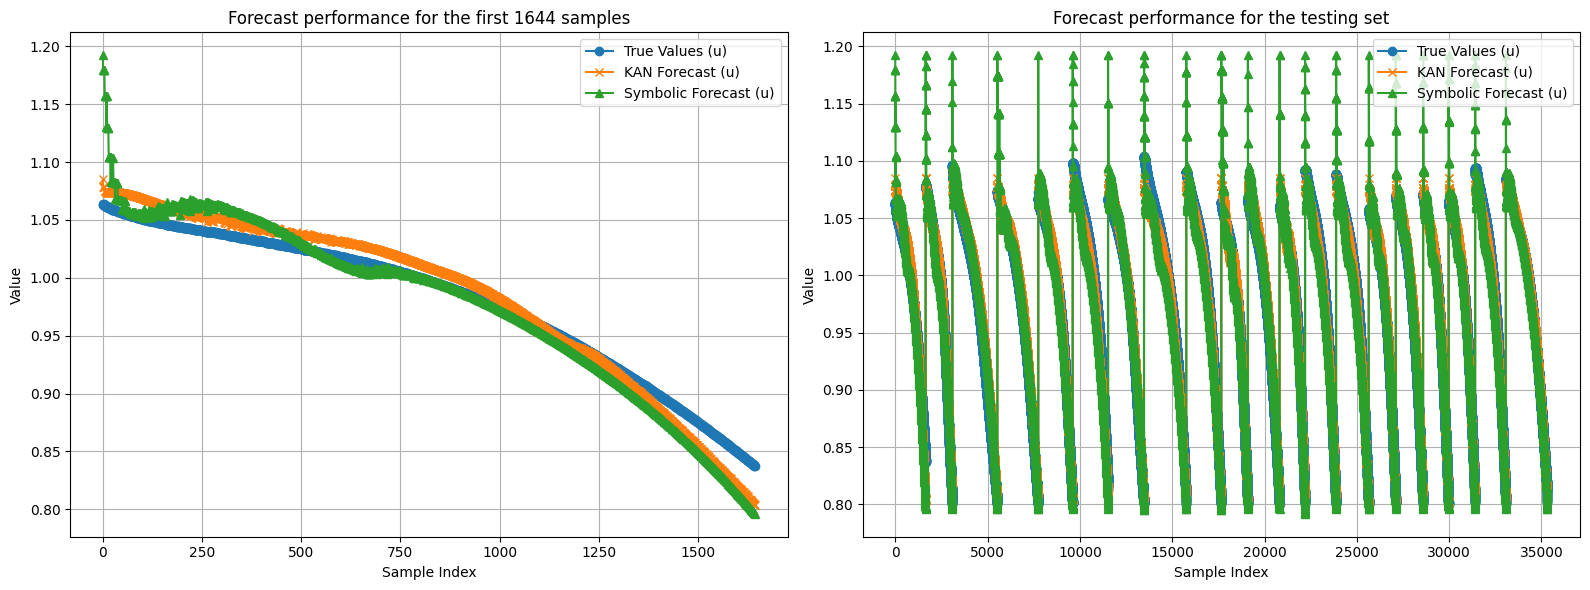

In [29]:
import matplotlib.pyplot as plt

# Set the interval for the first plot (first 50 samples)
interval = 1644

# Create the figure and axes for side-by-side plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the first interval 
axes[0].plot(true_values[:interval], label='True Values (u)', marker='o')
axes[0].plot(kan_forecasts[:interval], label='KAN Forecast (u)', marker='x')
axes[0].plot(symbolic_forecast1[:interval], label='Symbolic Forecast (u)', marker='^')
# axes[0].set(ylim=(0.79, 1.01),yticks=np.arange(0.80, 1.01, 0.05))

# Set the title and labels for the first plot
axes[0].set_title(f'Forecast performance for the first {interval} samples')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True)

# Plot the second interval (entire dataset)
axes[1].plot(true_values, label='True Values (u)', marker='o')
axes[1].plot(kan_forecasts, label='KAN Forecast (u)', marker='x')
axes[1].plot(symbolic_forecast1, label='Symbolic Forecast (u)', marker='^')
# axes[1].set(ylim=(0.81, 1.04),yticks=np.arange(0.85, 1.00, 0.05))

# Set the title and labels for the second plot
axes[1].set_title('Forecast performance for the testing set')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True)

# Save the plot to a specific location
save_path = '../Images/kan_hust_var2/paper_img/reality_vs_Kan_vs_symbolic.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
import moviepy.video.io.ImageSequenceClip

video_name='kan_hust_var2'
fps=5

all_image_files = []
for i in [1,2]:
    image_folder = '../Images/kan_hust_var2/video_img_f'+str(i)
    files = os.listdir(image_folder)
    train_index = []
    for file in files:
        if file[0].isdigit() and file.endswith('.jpg'):
            train_index.append(int(file[:-4]))
    train_index = np.sort(train_index)
    image_files = [image_folder+'/'+str(train_index[index])+'.jpg' for index in train_index]
    all_image_files += image_files
all_image_files.append(all_image_files[-1])   # 最后一帧需要重复，不然视频播放不出来

print("总图像数量：", len(all_image_files))
print("最后5张图像路径：", all_image_files[-5:])  # 查看最后几张是否正确
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(all_image_files, fps=fps)
clip.write_videofile("/data/huangjh/code/Projects_PINN_LiB/PIKAN4SOH/Videos/"+video_name+".mp4")

总图像数量： 101
最后5张图像路径： ['../Images/kan_hust_var2/video_img_f2/46.jpg', '../Images/kan_hust_var2/video_img_f2/47.jpg', '../Images/kan_hust_var2/video_img_f2/48.jpg', '../Images/kan_hust_var2/video_img_f2/49.jpg', '../Images/kan_hust_var2/video_img_f2/49.jpg']
MoviePy - Building video /data/huangjh/code/Projects_PINN_LiB/PIKAN4SOH/Videos/kan_hust_var2.mp4.
MoviePy - Writing video /data/huangjh/code/Projects_PINN_LiB/PIKAN4SOH/Videos/kan_hust_var2.mp4



MoviePy - Done !
MoviePy - video ready /data/huangjh/code/Projects_PINN_LiB/PIKAN4SOH/Videos/kan_hust_var2.mp4


In [38]:
import gc
torch.cuda.empty_cache()
gc.collect()

31271